<a href="https://colab.research.google.com/github/rtealwitter/dl-demos/blob/main/demo09-rl-basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reinforcement Learning Basics

In this demo, we will play around with the environments available through [Gym](https://www.gymlibrary.dev/).

We will assume familiarity with the reinforcement learning framework and the REINFORCE algorithm. Check out Chinmay Hegde's notes [here](https://chinmayhegde.github.io/dl-notes/notes/lecture09/) for a superb 14 minute introduction.

In the reinforcement learning framework, we have

* States (describing the environment),

* Actions (the choices we make), and

* Rewards (the value of the actions we take in the state).

Our goal is to formulate a *policy* that maps states to "good" actions.

We get data by interacting with the environment. We see a state $s_t$, respond with an action $a_t$ (chosen from our policy), receive reward $r_t$, and transition to the next state $s_{t+1}$.

We call a sequence of states and actions a *trajectory*.

$$
\tau = (s_0, a_0, s_1, a_1, \ldots, s_{L-1},a_{L-1})
$$

where $L$ is the *length* of the trajectory.

We will call the neural network describing our policy $\pi_\theta$ with parameters $\theta$. Then $\pi_\theta(\tau)$ is the probability we see trajectory $\tau$ when we follow policy $\pi_\theta$.

Because we want to maximize the reward, our loss function will be the *negative* reward for a trajectory.

$$
R(\tau) = \sum_{t=0}^{L-1} -r_t \gamma^t
$$

for discount factor $0 < \gamma < 1$.

There are many sources of randomness (the environment, the actions we take, and the reward) so the loss is the expected reward from a trajectory where we take actions according to our policy $\pi_\theta$.

$$
L(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau)]
$$

We want to minimize the loss by following its negative gradients. However, it's not obvious how the loss depends on the parameters $\theta$.

Using the log-derivative trick described [here](https://chinmayhegde.github.io/dl-notes/notes/lecture09/), we can write the gradient of the loss as

$$
\nabla L(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau) \nabla \log \pi_\theta(\tau)].
$$

## Libraries

For visualizing our agent playing, we'll need to load the following library.

In [7]:
# Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.distributions as distributions
import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym

import moviepy.video.io.ImageSequenceClip
from moviepy.editor import *

Check out a list of classic games [here](https://www.gymlibrary.dev/environments/classic_control/). We'll be experimenting with Cart Pole where the object is to keep a pole on top of a cart without falling.

In [16]:
env = gym.make('CartPole-v1', render_mode='human')

The observation space consists of four variables:

* Cart position (on a line)

* Cart velocity

* Pole angle

* Pole angular velocity


In [3]:
print(env.observation_space)
print(env.observation_space.shape)

Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
(4,)


We can take two actions: either push the cart to the left or to the right.

In [4]:
print(env.action_space)

Discrete(2)


The game is actually pretty hard! You can try your hand at it [here](https://jeffjar.me/cartpole.html). Now let's train a policy to beat it. We start by loading two different copies of the environment; one for training and one for testing.

In [28]:
train_env = gym.make('CartPole-v1', render_mode='rgb_array_list')
test_env = gym.make('CartPole-v1', render_mode='rgb_array_list')

We'll train a neural network that is actually incredibly simple: only two layers with dropout and ReLU.

In [8]:
class PolicyNet(nn.Module):
  def __init__(self, input_dim, hidden_dim, output_dim, dropout=.5):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.Dropout(dropout),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim)
    )

  def forward(self, x):
    return self.net(x)

As we've done many times before, we initialize our architecture and optimizer. However, the loss will be slightly more tricky to compute than normal.

In [9]:
input_dim = train_env.observation_space.shape[0]
print('input dim:', input_dim)

output_dim = train_env.action_space.n
print('output dim:', output_dim)

hidden_dim = 128

policy = PolicyNet(input_dim, hidden_dim, output_dim)
print(policy)

optimizer = optim.Adam(policy.parameters(), lr=0.01)

input dim: 4
output dim: 2
PolicyNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): Dropout(p=0.5, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [45]:
def evaluate(env, policy, return_frames=False, max_lim=None):
  policy.eval()

  terminated = False
  episode_reward = 0
  state = env.reset()[0]
  num_steps = 0

  while not terminated:
    state = torch.FloatTensor(state).unsqueeze(0)

    action_pred = policy(state)
    action_prob = F.softmax(action_pred, dim=-1)

    action = torch.argmax(action_prob, dim=-1) # we take the best
    state, reward, terminated, _, _= env.step(action.item())
    episode_reward += reward
    num_steps += 1

    if max_lim is not None and num_steps >= max_lim:
      break

  if return_frames:
    frames = env.render()
    return episode_reward, frames
  return episode_reward

reward, frames = evaluate(test_env, policy, return_frames = True, max_lim=1000)
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(frames, fps=50)
ipython_display(clip)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


In class, we described how to compute a single discounted reward of a trajectory. In practice, we want to leverage our data for more updates. We do this by considering the future discounted reward for *every* state in our trajectory.

In [11]:
def calculate_returns(rewards, discount_factor, normalize=True):
  returns = []
  R = 0
  # R_0 = r0 + r1 * discount + r2 * discount^2 + r3 * discount^3 + ...
  # R_1 = r1 + r2 * discount + r3 * discount^2 + ...
  # R_2 = r2 + r3 * discount + ...
  # Clever method for computing the future discounted reward
  # R_T = sum_{t = T}^L r_t * discount_factor ** {t-T}
  for r in reversed(rewards):
    # R_{T-1} = r + discount_factor * R_T
    R = r + R * discount_factor
    returns.insert(0,R)

  returns = torch.tensor(returns)
  # Remember we normalize to differentiate between
  # "good" and "bad" actions
  if normalize:
    returns = (returns - returns.mean()) / returns.std()

  return returns

Once we have returns and log probabilities of the actions we take, we will compute the loss and optimize.

In [12]:
def update_policy(returns, log_prob_actions, optimizer):
  returns = returns.detach() # Remove gradient information
  # Because we actually want to maximize returns,
  # we negate the expected sum for the minimization problem
  loss = - (returns * log_prob_actions).sum()
  optimizer.zero_grad()

  loss.backward()
  optimizer.step()

  return loss.item()

Now we write the training and evaluation functions. Notice how training in RL is more involved than our standard applications.

In [38]:
def train(env, policy, optimizer, discount_factor=.99):
  policy.train()

  log_prob_actions = []
  rewards = []
  done = False
  episode_reward = 0

  state = env.reset()[0]

  while not done:
    state = torch.FloatTensor(state).unsqueeze(0)
    action_pred = policy(state)
    action_prob = F.softmax(action_pred, dim = -1)

    dist = distributions.Categorical(action_prob)
    action = dist.sample() # we sample (rather than take the best)
    log_prob_action = dist.log_prob(action)

    state, reward, done, _, _ = env.step(action.item())

    log_prob_actions.append(log_prob_action)
    rewards.append(reward)

    episode_reward += reward

  log_prob_actions = torch.cat(log_prob_actions)
  returns = calculate_returns(rewards, discount_factor)
  loss = update_policy(returns, log_prob_actions, optimizer)

  return loss, episode_reward


Now we're ready to train. Notice the very jagged nature of the loss history. This is because RL is different from our regular training: our policy is stochastic and the reward is more "sparse".

In [41]:
max_episodes = 600
num_trials = 25
reward_threshold = 500
print_every = 10

train_rewards = []
test_rewards = []

for episode in range(1, max_episodes+1):
  loss, train_reward = train(train_env, policy, optimizer)
  test_reward = evaluate(test_env, policy)

  train_rewards += [train_reward]
  test_rewards += [test_reward]

  mean_train_rewards = np.mean(train_rewards[-num_trials:])
  mean_test_rewards = np.mean(test_rewards[-num_trials:])

  if episode % print_every == 0:
    print(f'| Episode: {episode:3} | Mean Train Rewards: {mean_train_rewards:5.1f} | Mean Test Rewards: {mean_test_rewards:5.1f} |')

  if mean_test_rewards >= reward_threshold:
    print(f'Reached reward threshold in {episode} episodes')
    break


| Episode:  10 | Mean Train Rewards:  71.2 | Mean Test Rewards: 143.9 |
| Episode:  20 | Mean Train Rewards:  69.0 | Mean Test Rewards: 103.2 |
| Episode:  30 | Mean Train Rewards:  76.6 | Mean Test Rewards: 114.8 |
| Episode:  40 | Mean Train Rewards:  96.6 | Mean Test Rewards: 131.1 |
| Episode:  50 | Mean Train Rewards: 130.5 | Mean Test Rewards: 157.0 |
| Episode:  60 | Mean Train Rewards: 191.2 | Mean Test Rewards: 268.8 |
Reached reward threshold in 63 episodes


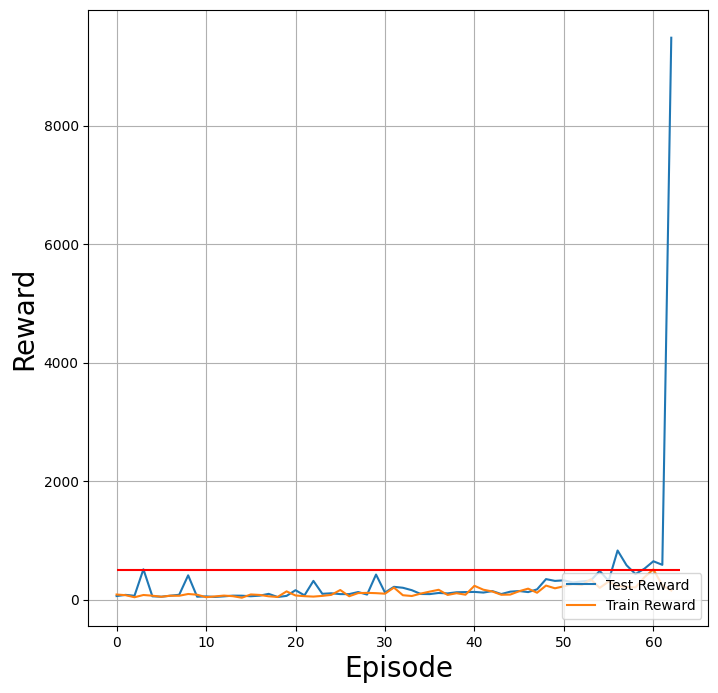

In [42]:
plt.figure(figsize=(8,8))
plt.plot(test_rewards, label='Test Reward')
plt.plot(train_rewards, label='Train Reward')
plt.xlabel('Episode', fontsize=20)
plt.ylabel('Reward', fontsize=20)
plt.hlines(reward_threshold, 0, len(test_rewards), color='r')
plt.legend(loc='lower right')
plt.grid()

In [43]:
_, frames = evaluate(test_env, policy, return_frames = True, max_lim=1000)
clip = moviepy.video.io.ImageSequenceClip.ImageSequenceClip(frames, fps=50)
ipython_display(clip)

Moviepy - Building video __temp__.mp4.
Moviepy - Writing video __temp__.mp4



Moviepy - Done !
Moviepy - video ready __temp__.mp4


ValueError: The duration of video __temp__.mp4 (84.6) exceeds the 'maxduration' attribute. You can increase 'maxduration', by passing 'maxduration' parameterto ipython_display function.But note that embedding large videos may take all the memory away !